In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
wine=pd.read_csv('Wine dataset.csv',header=None,usecols=[0,1,2])
wine.columns=['Class_label','Alcohol','Malic_acid']

In [11]:
wine

,Class_label,Alcohol,Malic_acid
0,class,Alcohol,Malic acid
1,1,14.23,1.71
2,1,13.2,1.78
3,1,13.16,2.36
4,1,14.37,1.95
...,...,...,...
174,3,13.71,5.65
175,3,13.4,3.91
176,3,13.27,4.28
177,3,13.17,2.59


In [12]:
wine.dtypes

Class_label    object
Alcohol        object
Malic_acid     object
dtype: object

<Axes: xlabel='Alcohol', ylabel='Density'>

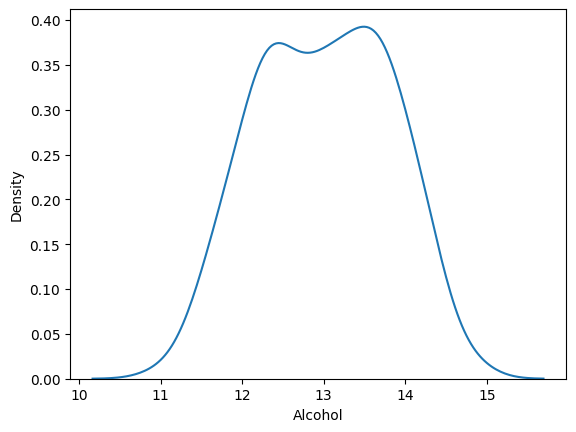

In [13]:
wine['Alcohol']=pd.to_numeric(wine['Alcohol'],errors='coerce')
sns.kdeplot(data=wine,x='Alcohol')  
    # the value are in obj so covert into numerical value

In [14]:
wine.dtypes 

Class_label     object
Alcohol        float64
Malic_acid      object
dtype: object

<Axes: xlabel='Malic_acid', ylabel='Density'>

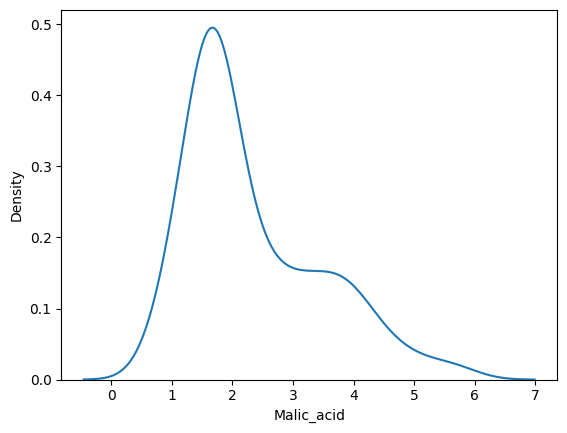

In [15]:
wine['Malic_acid']=pd.to_numeric(wine['Malic_acid'],errors='coerce')
sns.kdeplot(data=wine,x='Malic_acid')

<Axes: xlabel='Malic_acid', ylabel='Density'>

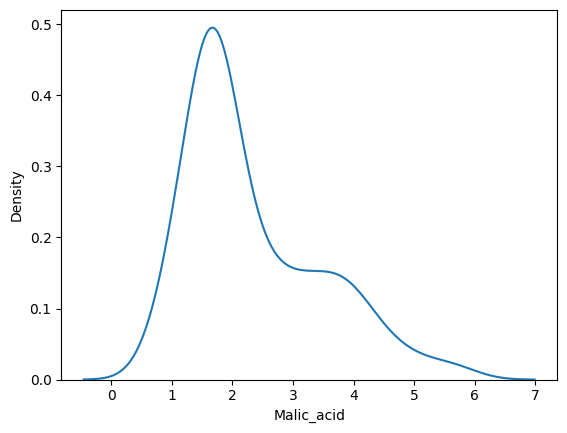

In [17]:
wine['Class_label']=pd.to_numeric(wine['Class_label'],errors='coerce')
sns.kdeplot(data=wine,x='Malic_acid')

In [18]:
from sklearn.model_selection import train_test_split


In [19]:
x_train,x_test,y_train,y_test=train_test_split(wine.drop('Class_label',axis=1),wine['Class_label'],test_size=0.3,random_state=0)

In [20]:
x_train.shape,x_test.shape

((125, 2), (54, 2))

In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
scaler.fit(x_train)
x_train_Scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [26]:
x_train_Scaled=pd.DataFrame(x_train_Scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [27]:
np.round(x_train.describe(),1)      # before minmax

,Alcohol,Malic_acid
count,124.0,124.0
mean,13.0,2.3
std,0.9,1.1
min,11.0,0.7
25%,12.3,1.5
50%,13.0,1.8
75%,13.7,3.0
max,14.8,5.6


In [29]:
np.round(x_train_Scaled.describe(),1)    # now see after min max the value f min =0,max=1

,Alcohol,Malic_acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.3,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


Text(0.5, 1.0, 'after minmax')

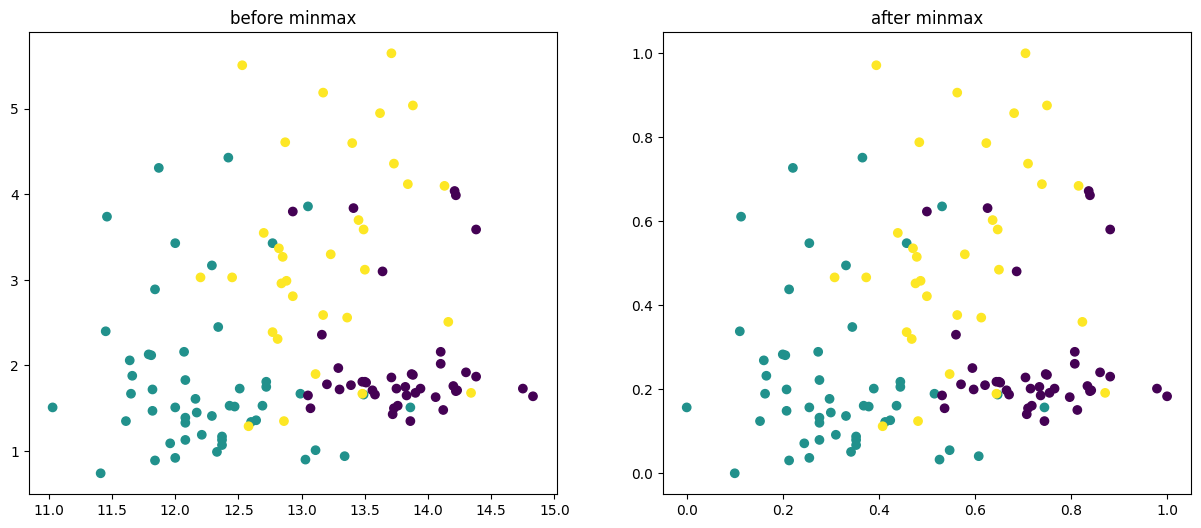

In [30]:
fig,(ax1,ax2)=plt.subplots(ncols=2,  figsize=(15,6))
ax1.scatter(x_train['Alcohol'],x_train['Malic_acid'],c=y_train)
ax1.set_title('before minmax scaling')
ax2.scatter(x_train_Scaled['Alcohol'],x_train_Scaled['Malic_acid'],c=y_train)
ax2.set_title('after minmax scaling')

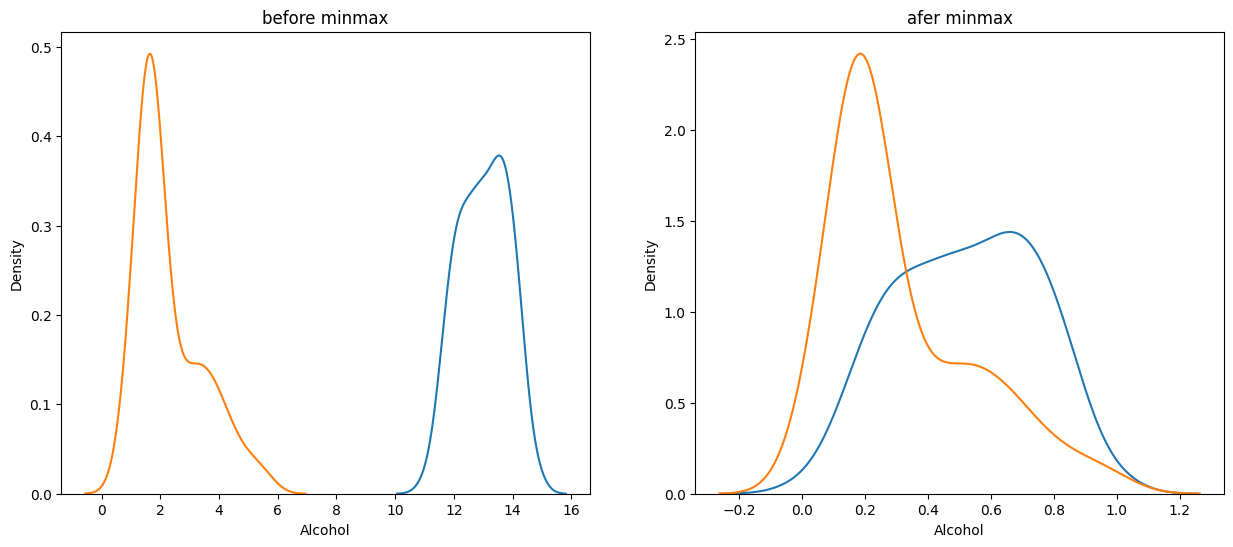

In [44]:
fig,(ax1,ax2)=plt.subplots(ncols=2,  figsize=(15,6))

sns.kdeplot(x_train['Alcohol'],ax=ax1)
sns.kdeplot(x_train['Malic_acid'],ax=ax1)
ax1.set_title('before minmax')
sns.kdeplot(x_train_Scaled['Alcohol'],ax=ax2)
sns.kdeplot(x_train_Scaled['Malic_acid'],ax=ax2)
ax2.set_title('afer minmax')
plt.show()
